In [280]:
import numpy as np
import matplotlib.pyplot as plt


# 1. Creation of transducer object

In [281]:
import numpy as np
import pyvista as pv
import meshio
from time import time as TIME


class LinearArrayTransducer:
    def __init__(
        self,
        *,
        n_elements,
        element_width_mm,
        element_height_mm,
        kerf_mm,
        elevation_focus_mm,
        no_sub_x,
        no_sub_y,
        frequency_Hz = None
    ):
        """
        Defines a linear array transducer geometry with optional elevation focusing.

        Parameters
        ----------
        n_elements : int
            Number of elements in the array.
        element_width : float
            Width of each element (m).
        element_height : float
            Height of each element (m).
        kerf : float
            Gap between elements (m).
        elevation_focus : float or None
            Elevation focus distance (m). If None, elements are flat.
        no_sub_x, no_sub_y : int
            Number of subdivisions (patches) in x (element width) and y (element height).
            
        """
        start_time = TIME()
        element_height, element_width = element_height_mm *1e-3, element_width_mm *1e-3
        kerf, elevation_focus = kerf_mm *1e-3, elevation_focus_mm *1e-3
        self.n_elements = n_elements
        self.el_w = element_width # m
        self.el_h = element_height  # m
        self.kerf = kerf  # m
        self.elev_focus = elevation_focus  # m
        self.no_sub_x = no_sub_x
        self.no_sub_y = no_sub_y
        
        if elevation_focus is not None and elevation_focus > 0 and no_sub_y < 2:
            raise ValueError("Elevation focus requires at least 2 subdivisions in y to model elevation focusing.")

        if frequency_Hz is not None:
            self.fc = frequency_Hz
        else:
            self.fs = 1
            print("Warning: No central frequency provided. Defaulting to 1 Hz.")

        # Per-element apodization weights and delay placeholders
        self.apodization = np.ones(n_elements, dtype=float)
        self.delays = np.zeros(n_elements, dtype=float)

        # Compute element centers along x-axis
        total_width = n_elements * element_width + (n_elements - 1) * kerf
        start_x = -total_width / 2 + element_width / 2
        self.element_centers = np.array([
            [start_x + i * (element_width + kerf), 0.0, 0.0]
            for i in range(n_elements)
        ])

        # Build subdivisions boundaries and areas, apply elevation curvature
        self.sub_quad_verts, self.sub_area, self.sub_el_idx = self._build_subdivisions()
        end_time = TIME()
        print(f"Transducer initialized in {end_time - start_time:.4f} seconds.")

    def _build_subdivisions(self):
        """
        Generate vertices for each subdivision quad of each element, applying elevation focus curvature if set.
        Returns
        -------
        sub_quad_verts : list of arrays (4x3) for each patch quad vertices
        sub_area : float, area of each patch
        sub_el_idx : list mapping each patch to its element index
        """
        # Local grid edges in element coordinates
        xs = np.linspace(-self.el_w/2, self.el_w/2, self.no_sub_x + 1)
        ys = np.linspace(-self.el_h/2, self.el_h/2, self.no_sub_y + 1)

        patch_area = (self.el_w / self.no_sub_x) * (self.el_h / self.no_sub_y)

        quads = []
        el_indices = []
        for idx, center in enumerate(self.element_centers):
            for i in range(self.no_sub_x):
                for j in range(self.no_sub_y):
                    # four corners of the patch in local coords
                    corners_local = np.array([
                        [xs[i],   ys[j],   0.0],
                        [xs[i+1], ys[j],   0.0],
                        [xs[i+1], ys[j+1], 0.0],
                        [xs[i],   ys[j+1], 0.0]
                    ])
                    # translate to global x,y
                    corners = corners_local.copy()
                    corners[:,0] += center[0]
                    corners[:,1] += center[1]
                    # apply elevation curvature in z
                    if self.elev_focus is not None and self.elev_focus > 0:
                        y_vals = corners[:,1]
                        z_offset = self.elev_focus - np.sqrt(np.clip(self.elev_focus**2 - y_vals**2, 0, None))
                        corners[:,2] += z_offset
                    else:
                        corners[:,2] += center[2]
                    quads.append(corners)
                    el_indices.append(idx)
        return quads, patch_area, el_indices

    def set_apodization(self, weights):
        """Set per-element apodization weights (length = n_elements)."""
        weights = np.asarray(weights, dtype=float)
        if weights.shape[0] != self.n_elements:
            raise ValueError("Apodization array must match number of elements.")
        self.apodization = weights

    def set_delays(self, delays):
        """Set per-element delays in seconds (length = n_elements)."""
        delays = np.asarray(delays, dtype=float)
        if delays.shape[0] != self.n_elements:
            raise ValueError("Delay array must match number of elements.")
        self.delays = delays

    def get_mesh(self):
        """
        Returns a PyVista PolyData mesh of all subdivided quads, with per-cell apodization scalars.
        """
        # Aggregate all points and faces
        verts = []
        faces = []
        scalars = []
        pt_index = 0
        for quad, el_idx in zip(self.sub_quad_verts, self.sub_el_idx):
            # quad is 4x3 array, create face [4, p0, p1, p2, p3]
            verts.extend(quad.tolist())
            face = [4, pt_index, pt_index+1, pt_index+2, pt_index+3]
            faces.append(face)
            scalars.append(self.apodization[el_idx])
            pt_index += 4
        # Flatten verts and faces
        verts = np.array(verts)*1e3  # Convert to mm for visualization
        faces_flat = np.hstack(faces)
        mesh = pv.PolyData(verts, faces_flat)
        mesh.cell_data['Apodization'] = np.array(scalars)
        return mesh


# 2. Spatial impulse response computation

In [282]:
import numpy as np
from scipy.interpolate import interp1d
from tqdm import tqdm
from numba import njit

@njit
def _compute_rectangle_SIR_numba(wx, wy, xp, yp, l, c0, apod, delay):
    # Vectorized far-field SIR for a single rectangle patch
    Dt1 = min(abs(wx * xp / c0), abs(wy * yp / c0))
    Dt2 = max(abs(wx * xp / c0), abs(wy * yp / c0))
    area = wx * wy / (2 * np.pi * l)

    t1 = l / c0 - (Dt1 + Dt2) * 0.5
    t2 = t1 + Dt1
    t3 = t1 + Dt2
    t4 = t1 + Dt1 + Dt2

    # avoid invalid conditions
    if not (t1 <= t2 <= t3 <= t4):
        raise ValueError("Invalid time sequence in patch SIR")

    time_window = ((t2 - t1) + (t4 - t3)) * 0.5 + (t3 - t2)
    h_max = area / time_window * apod

    t = np.empty(4)
    h = np.empty(4)
    t[0], t[1], t[2], t[3] = t1 + delay, t2 + delay, t3 + delay, t4 + delay
    h[0], h[1], h[2], h[3] = 0.0, h_max, h_max, 0.0
    return t, h

class PyField_v1:
    def __init__(self, transducer):
        self.tx = transducer
        self.c = 1540.0
        self.fc = transducer.fc
        self.fs = 100e6
        # precompute patch data
        el_h = self.tx.el_h / self.tx.no_sub_y
        el_w = self.tx.el_w / self.tx.no_sub_x
        centers = []
        apods = []
        delays = []
        for elem in range(self.tx.n_elements):
            for sub in range(self.tx.no_sub_x * self.tx.no_sub_y):
                verts = self.tx.sub_quad_verts[elem * (self.tx.no_sub_x * self.tx.no_sub_y) + sub]
                centers.append(verts.mean(axis=0))
                apods.append(self.tx.apodization[elem])
                delays.append(self.tx.delays[elem])
        self._centers = np.array(centers)
        self._apods = np.array(apods)
        self._delays = np.array(delays)
        self._wx = el_w
        self._wy = el_h

    def set_field(self, name_struct_str, value_float):
        """
        Dynamically modifies a class property if it exists.

        Parameters
        ----------
        name_struct_str : str
            The name of the property to modify.
        value_float : float
            The new value to assign to the property.

        Raises
        ------
        AttributeError
            If the property does not exist in the class.
        TypeError
            If the value is not a float.
        """
        if not isinstance(value_float, (float, int)):  # Allow integers as well
            raise TypeError(f"The value must be a float or int, got {type(value_float).__name__}.")
        
        if hasattr(self, name_struct_str):
            setattr(self, name_struct_str, value_float)
            print(f"Property '{name_struct_str}' updated to {value_float}.")
        else:
            raise AttributeError(f"Property '{name_struct_str}' does not exist in the class.")

    def show_transducer(self, kwargs= None):
        """
        Visualize the transducer surface mesh and apodization with PyVista.
        """
        mesh = self.tx.get_mesh()
        plotter = pv.Plotter()
        plotter.add_mesh(
            mesh,  # Convert to mm for visualization
            scalars='Apodization',
            cmap='viridis',
            show_scalar_bar=True,
            scalar_bar_args={'title':'Apodization', 'vertical': True},
            opacity=1.0,
            show_edges=True,
        )
        plotter.add_axes()
        plotter.show_grid(font_size = 10, xtitle = "X (mm)", ytitle = "Y (mm)", ztitle = "Z (mm)", show_zlabels=False)
        plotter.show()

    def spatial_impulse_response_subdivision(self, field_points, return_all=False):

        start_comput_time = TIME()
        pts = np.atleast_2d(field_points)
        P = pts.shape[0]
        M = self._centers.shape[0]

        # collect all patch times & amplitudes
        t_tx = np.zeros((P, M, 4))
        h_tx = np.zeros((P, M, 4))

        # progress bar
        for p in tqdm(range(P), desc="Computing SIR", unit="pt"):
            xp, yp, zp = pts[p]
            diffs = self._centers - pts[p]
            dists = np.linalg.norm(diffs, axis=1)
            # normalized directions
            dirs = diffs / dists[:, None]
            for i in range(M):
                t_patch, h_patch = _compute_rectangle_SIR_numba(
                    self._wx, self._wy,
                    dirs[i,0], dirs[i,1],
                    dists[i], self.c,
                    self._apods[i], self._delays[i]
                )
                t_tx[p, i, :] = t_patch
                h_tx[p, i, :] = h_patch

        # flatten times and build global time vector
        all_times = np.unique(t_tx.reshape(-1))
        start, end = all_times.min(), all_times.max()
        duration = end - start
        num_samples = int(np.ceil(duration * self.fs))
        n2 = 2 ** max(int(np.ceil(np.log2(num_samples))) + 1, 5)
        global_time = np.linspace(start, start + n2/self.fs, n2, endpoint=False)

        # aggregate
        h_subdiv = np.zeros((P, n2))
        for p in tqdm(range(P), desc="Interpolating", unit="pt"):
            # sum contributions
            h_all = np.zeros(all_times.shape)
            for i in range(M):
                h_all += np.interp(all_times, t_tx[p,i], h_tx[p,i])
            h_subdiv[p] = np.interp(global_time, all_times, h_all)


        print(f"Total computation time: {TIME() - start_comput_time:.4f} seconds.")
        if return_all:
            return global_time, h_subdiv.T, t_tx, h_tx
        return start, h_subdiv.T
    
    def spatial_impulse_response(self, field_points, return_all=False):

        start_comput_time = TIME()
        pts = np.atleast_2d(field_points)
        P, M = pts.shape[0], self._centers.shape[0]
        # compute all patch events
        t_events = np.empty((P, M, 5))  # t1,t2,t3,t4,h_max
        for p in tqdm(range(P), desc="Compute patches", unit="pt"):
            diffs = self._centers - pts[p]
            dists = np.linalg.norm(diffs, axis=1)
            dirs = diffs / dists[:, None]
            for i in range(M):
                t_patch, h_patch = _compute_rectangle_SIR_numba(
                    self._wx, self._wy,
                    dirs[i,0], dirs[i,1],
                    dists[i], self.c,
                    self._apods[i], self._delays[i]
                )
                t_events[p, i, 0:4] = t_patch
                t_events[p, i, 4] = h_patch[1]

        # global time grid
        all_times = np.unique(t_events[:,:, :4].ravel())
        start, end = all_times.min(), all_times.max()
        duration = end - start
        num_samples = int(np.ceil(duration * self.fs))
        n2 = 2 ** max(int(np.ceil(np.log2(num_samples))) + 1, 5)
        t_global = np.linspace(start, start + n2/self.fs, n2, endpoint=False)
        h_out = np.zeros((P, n2))
        # accumulate trapezoids directly
        for p in tqdm(range(P), desc="Accumulate SIR", unit="pt"):
            for i in range(M):
                t1, t2, t3, t4, h_max = t_events[p,i]
                # index bounds
                k1 = int(np.searchsorted(t_global, t1))
                k2 = int(np.searchsorted(t_global, t2))
                k3 = int(np.searchsorted(t_global, t3))
                k4 = int(np.searchsorted(t_global, t4))
                
                # rising edge
                if k2 > k1:
                    for k in range(k1, k2):
                        h_out[p,k] += h_max * ((t_global[k] - t1) / (t2 - t1))
                # plateau
                if k3 > k2:
                    h_out[p, k2:k3] += h_max
                # falling edge
                if k4 > k3:
                    for k in range(k3, k4):
                        h_out[p,k] += h_max * (1 - (t_global[k] - t3) / (t4 - t3))
                        
        print(f"Total computation time: {TIME() - start_comput_time:.4f} seconds.")
        if return_all:
            return t_global, h_out.T, t_events
        return start, h_out.T

# 3. Visualization

## 3.1. Visualization of spatial impulse response (SIR).

In [283]:
def plot_apodization_and_delays(tx):
    """
    Plot the apodization and delays of the transducer at specified field points.
    Parameters
    ----------
    tx : LinearArrayTransducer
        The transducer object.
    """

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].plot(tx.apodization)
    ax[0].set_title("Apodization")
    ax[0].set_xlabel("Element index")
    ax[0].set_ylabel("Apodization")
    ax[0].grid()

    ax[1].plot(tx.delays*1e6)
    ax[1].set_title("Delays (us)")
    ax[1].set_xlabel("Element index")
    ax[1].set_ylabel("Delay (us)")
    ax[1].grid()

    plt.tight_layout()
    plt.show()

    return fig, ax

def plot_sir_subdivision(tx, field, field_point):
    """
    Plot the SIR for each subdivision of the transducer at specified field points.
    Parameters
    ----------
    tx : LinearArrayTransducer
        The transducer object.
    t_tx : ndarray	
        Time vector for the impulse response.
    h_tx : ndarray
        SIR waveform at each of the P points.
    """
    time, h, t_tx, h_tx = field.spatial_impulse_response_subdivision(field_point*1e-3, return_all=True) 
    print(f"SIR shape: {h.shape} ")
    print(f"start_time: {time[0]}")
    # Plot the SIR for each subdivision
    n_elem = tx.n_elements
    n_sub_div = tx.no_sub_x * tx.no_sub_y
    fig, ax = plt.subplots(2, 1, figsize=(10, 10))
    for p in range(h_tx.shape[0]):
        for elem in range(n_elem):
            for sub_ind in range(n_sub_div):
                # for sub_y in range(tx.no_sub_y):
                    i = elem * n_sub_div + sub_ind
                    ax[0].plot(t_tx[p, i, :]*1e6, h_tx[p, i, :], label=f"Patch {p+1}")
                    if elem < n_elem//2:
                        ax[0].text(t_tx[p, i, 1]*1e6, h_tx[p, i, 1], f"{elem}", fontsize=8)
                    else:
                        ax[0].text(t_tx[p, i, 2]*1e6, h_tx[p, i, 1], f"{elem}", fontsize=8)

    ax[0].set_title("SIR for each subdivision")
    ax[0].set_xlabel("Time (us)")
    ax[0].set_ylabel("SIR")
    ax[0].grid()
    
    ax[1].plot(time*1e6, h)
    ax[1].set_title("SIR for transducer")
    ax[1].set_xlabel("Time (us)")
    ax[1].set_ylabel("SIR")
    ax[1].grid()

    plt.tight_layout()

    return fig, ax
    





### 3.1.1. Creation of Transducer

In [284]:
# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5  # MHz

c = 1540.0  # speed of sound in soft tissue (m/s)

tx = LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 2,
    frequency_Hz       = tx_freq*1e6,  # MHz
)


Transducer initialized in 0.0020 seconds.


### 3.1.2. No apodization, No delay-law

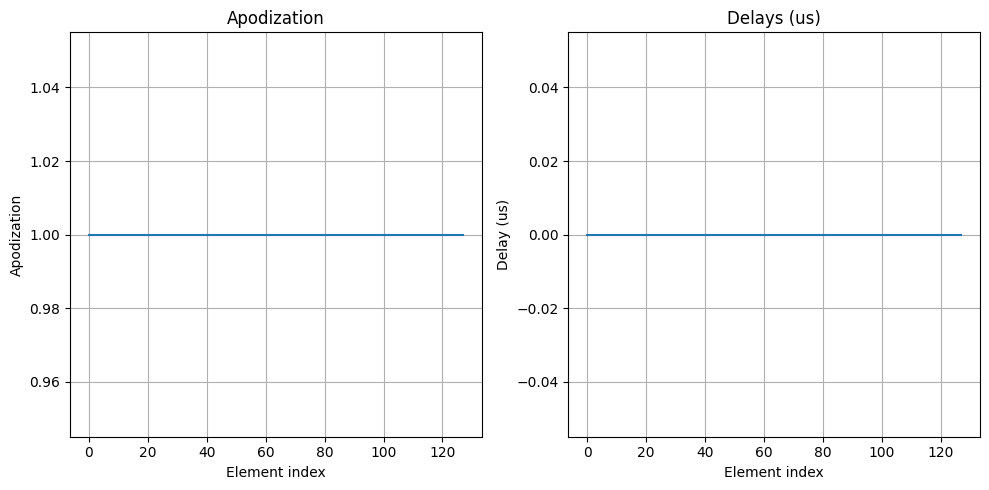

In [285]:
fig, ax = plot_apodization_and_delays(tx)


In [286]:
# Wrap into PyField
field = PyField_v1(tx)

# Select the field point for the SIR computation
field_point = np.array([0, 0, 8])  # mm

Interpolating: 100%|██████████| 1/1 [00:00<00:00, 786.63pt/s]


Total computation time: 0.1345 seconds.
SIR shape: (512, 1) 
start_time: 5.177537148677943e-06


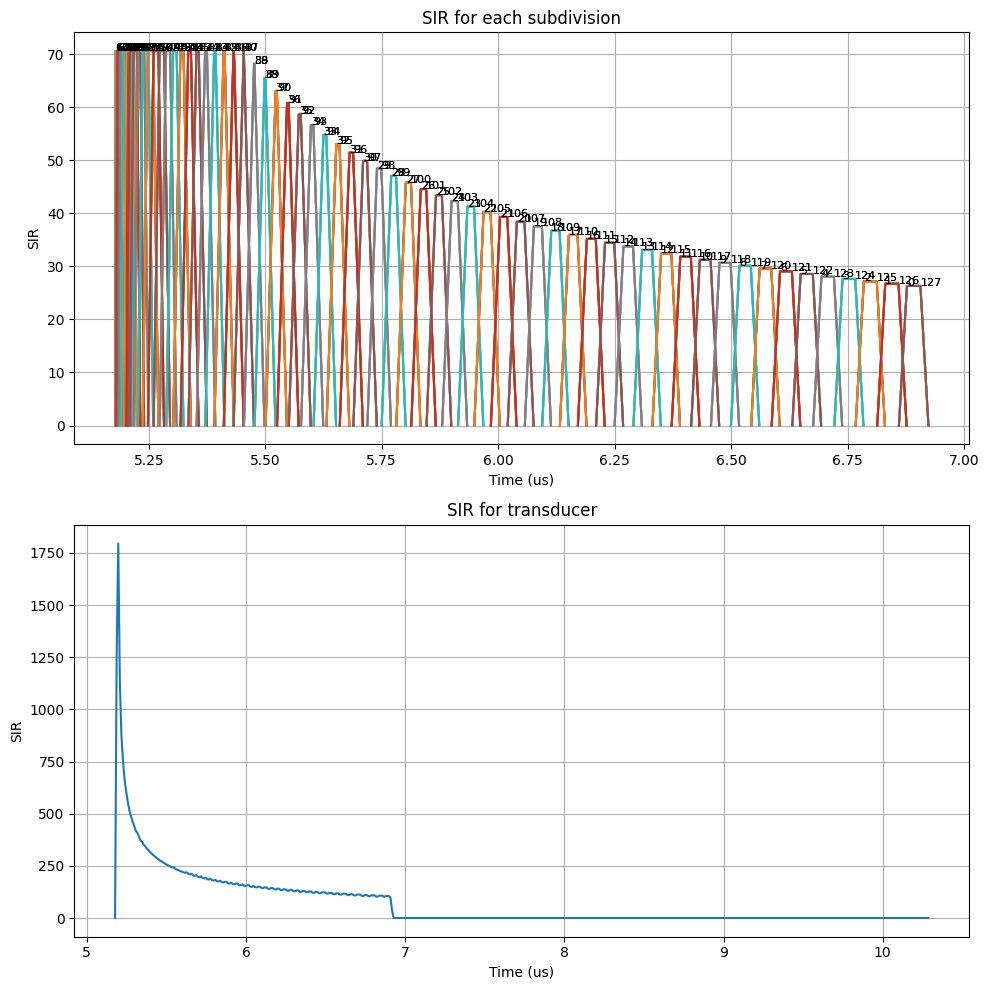

In [287]:
fig = plot_sir_subdivision(tx, field, field_point)

### 3.1.3. Apodzation and delay-law

In [288]:
field_point = np.array([1, 0, 8])  # mm
focus_mm =  np.array([0, 0, 8])  # mm
delays = np.linalg.norm(tx.element_centers - focus_mm*1e-3, axis=1) / c 
delays = delays.min()- delays  # time delays for focusing
tx.set_delays(delays)
# tx.set_apodization(np.hanning(n_elements))

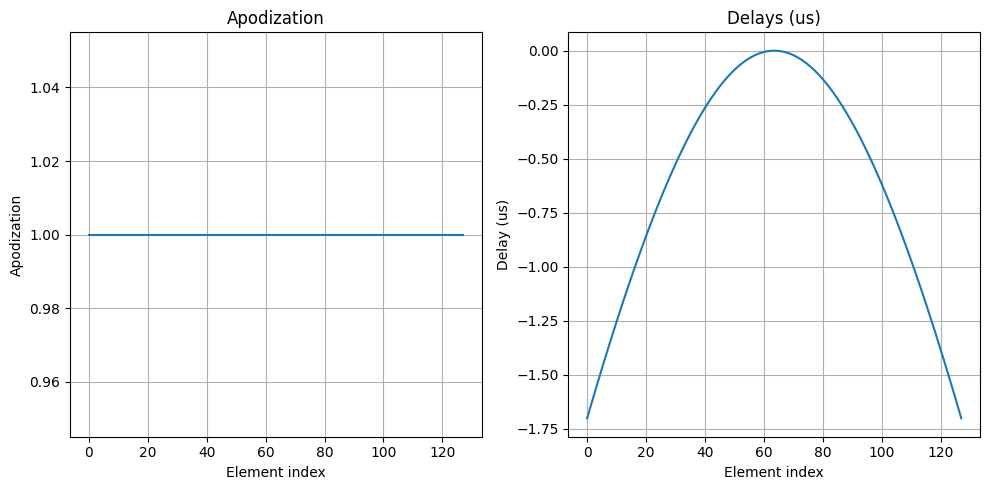

In [289]:
fig, ax = plot_apodization_and_delays(tx)

In [290]:
# Wrap into PyField
field = PyField_v1(tx)

Interpolating: 100%|██████████| 1/1 [00:00<00:00, 997.46pt/s]


Total computation time: 0.0060 seconds.
SIR shape: (256, 1) 
start_time: 4.751565173537317e-06


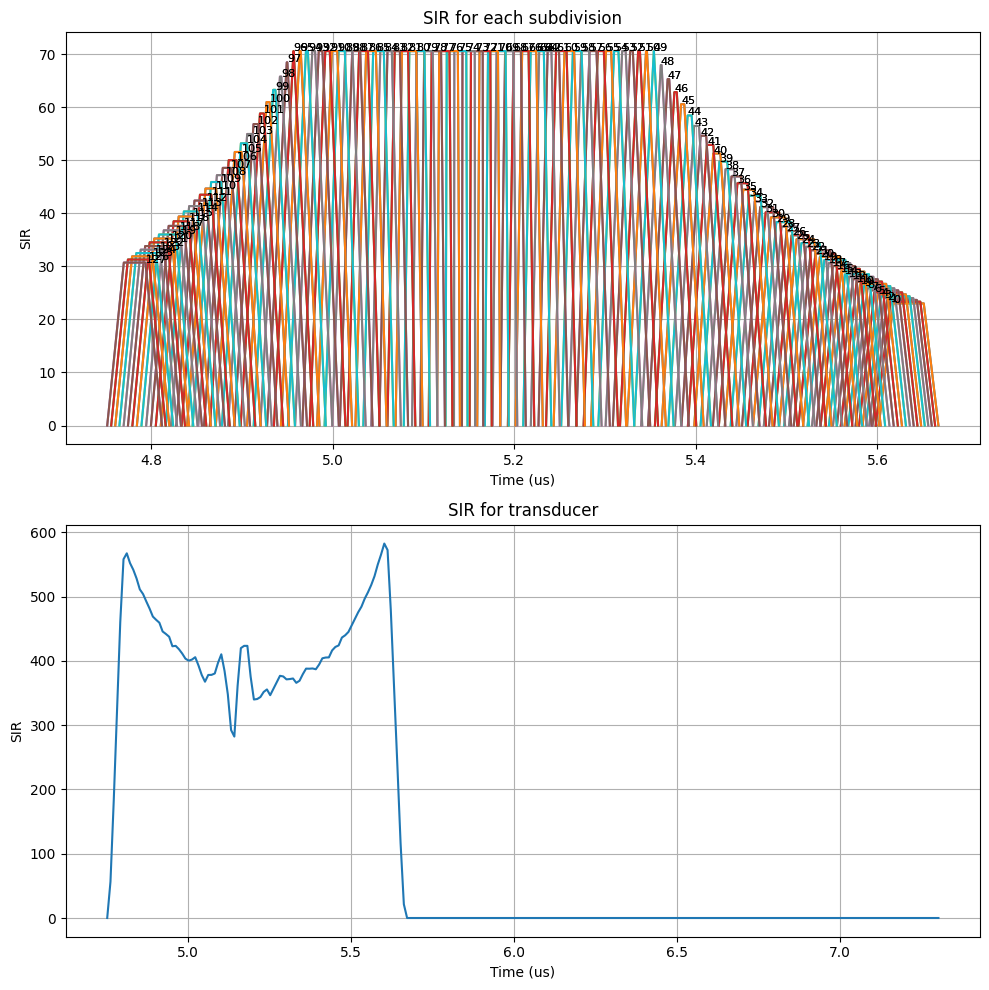

In [291]:
fig = plot_sir_subdivision(tx, field, field_point)

In [292]:

field.show_transducer()

Widget(value='<iframe src="http://localhost:60878/index.html?ui=P_0x182eb416930_6&reconnect=auto" class="pyvis…

# 4. Real implementation and calculation of field pressure map

## 4.1. Creation of Transducer

In [293]:
# Create transducer with elevation focus
n_elements = 128
pitch_mm = 0.11
element_width_mm = 0.108
element_height_mm = 1.5
elevation_focus_mm = 8  # mm
tx_freq = 12.5  # MHz

c = 1540.0  # speed of sound in soft tissue (m/s)

tx = LinearArrayTransducer(
    n_elements         = n_elements,
    element_width_mm   = element_width_mm,
    element_height_mm  = element_height_mm,
    elevation_focus_mm = elevation_focus_mm,
    kerf_mm            = pitch_mm - element_width_mm,
    no_sub_x           = 1,
    no_sub_y           = 10,
    frequency_Hz       = tx_freq*1e6,  # MHz
)


Transducer initialized in 0.0095 seconds.


In [294]:
focus_mm = np.array([0,0,8])  # mm
delays = np.linalg.norm(tx.element_centers - focus_mm*1e-3, axis=1) / c
delays = delays.min() - delays  # time delays for focusing
tx.set_delays(delays)

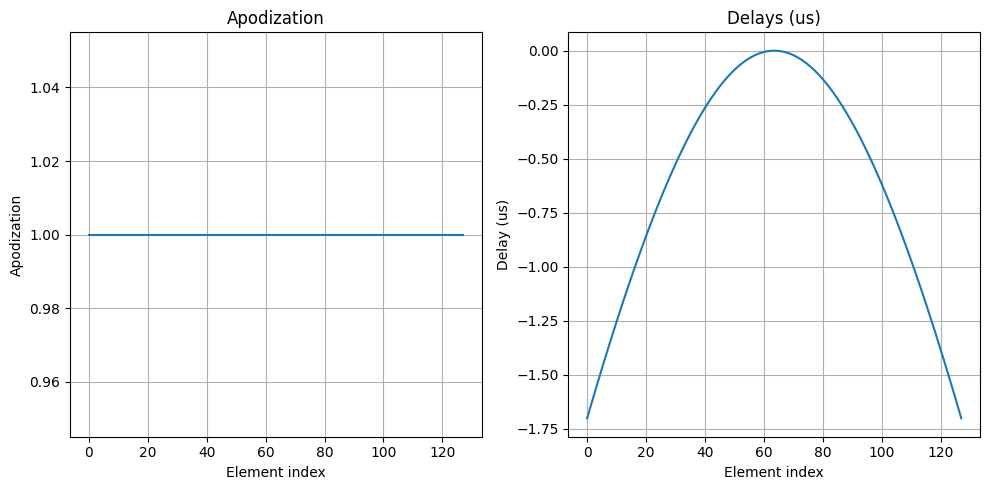

In [295]:
fig = plot_apodization_and_delays(tx)

## 4.2. Creation of grid

In [296]:
def create_simulation_grid(simulation_struct):
    """
    Create a simulation mesh for the ultrasound field.
    
    Parameters
    ----------
    simulation_struct : dict
        Dictionary containing the simulation parameters.
    
    Returns
    -------
    grid_points : ndarray
        Array of points in the simulation space.
    """
    # Create a grid of points in the simulation space
    [x0, xf], [y0, yf], [z0, zf] = simulation_struct["x_extent"], simulation_struct["y_extent"], simulation_struct["z_extent"]
    Nx = int((xf-x0) / simulation_struct["dx"])
    Ny = int((yf-y0) / simulation_struct["dy"])
    Nz = int((zf-z0) / simulation_struct["dz"])
    if Nx % 2 == 0 :
        Nx += 1 
    if Ny % 2 == 0 :
        Ny += 1
    if Nz % 2 == 0 :
        Nz += 1

    x = np.linspace(x0,xf, Nx)
    y = np.linspace(y0,yf, Ny)
    z = np.linspace(z0,zf, Nz)
    # Create a meshgrid of points
    grid_points = np.array(np.meshgrid(x, y, z)).T.reshape(-1, 3)

    return x*1e3, y*1e3, z*1e3, grid_points

In [297]:
simulation_struct = {
    "x_extent" : [-0.5e-3, 0.5e-3],
    "y_extent" : [-0.7e-3, 0.7e-3],
    "z_extent" : [7.2e-3, 8.8e-3],
    "dx" : 0.1e-3,
    "dy" : 0.1e-3,
    "dz" : 0.1e-3,
}

x, y, z, grid_points = create_simulation_grid(simulation_struct)

In [298]:
print(grid_points.shape, x.shape, y.shape, z.shape)

(2805, 3) (11,) (15,) (17,)


## 4.3. Compute SIR and Pressure field

In [299]:
def compute_pressure_from_SIR(h, x, y, z, Frequencies):
    """
    Compute the pressure field from the SIR.
    
    Parameters
    ----------
    h : ndarray
        The SIR data.
    x, y, z : ndarray
        The grid points in the simulation space.
    Frequencies : list
        List of frequencies for the simulation.
        Frequencies[0] is the central frequency of the transducer.
        Frequencies[1] is the sampling frequency.
    Returns
    -------
    pressure : ndarray
        The computed pressure field.
    """

    freq_searched = Frequencies[0]  #  Hz
    sampling_frequency = Frequencies[1]  # Hz

    print(f"Original h shape: {h.shape}")
    spatial_impulse_response_field = h.reshape( -1, z.shape[0], x.shape[0], y.shape[0]).transpose(0, 2, 3, 1)
    print(f"Reshaped h shape: {spatial_impulse_response_field.shape}")

    # Perform FFT along the first axis
    spatial_impulse_response_field_FT = np.fft.fft(spatial_impulse_response_field, axis=0)
    # Generate the frequency vector
    freq_vect = np.linspace(0, sampling_frequency, spatial_impulse_response_field_FT.shape[0])

    # Find the index of the desired frequency
    idx_freq = np.argmin(np.abs(freq_vect - freq_searched))
    print(f"Frequency searched: {freq_searched} Hz, Closest found: {freq_vect[idx_freq]} Hz")

    # Amplitude for the given frequency
    amp_response_tx_freq = np.abs(spatial_impulse_response_field_FT[idx_freq, :, :, :])
    
    pressure_field = amp_response_tx_freq/np.max(amp_response_tx_freq)

    return pressure_field


In [300]:
start_time, h = field.spatial_impulse_response(grid_points) 

Accumulate SIR: 100%|██████████| 2805/2805 [00:05<00:00, 541.04pt/s]

Total computation time: 6.6686 seconds.


In [301]:
pressure_field = compute_pressure_from_SIR(h, x, y, z, [field.fc, field.fs])

Original h shape: (512, 2805)
Reshaped h shape: (512, 11, 15, 17)
Frequency searched: 12500000.0 Hz, Closest found: 12524461.839530332 Hz


## 4.4. Visualize results

In [302]:
def plot_pressure_field(pressure_field, x, y, z):
    """
    Plot the pressure field in 3D.
    
    Parameters
    ----------
    pressure_field : ndarray
        Pressure field data.
    x, y, z : ndarray
        Coordinate arrays.
    """
    # If x, y, z are 1D (common case)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    dz = z[1] - z[0]

    nx, ny, nz = pressure_field.shape

    # Create the 3D UniformGrid
    pressure_vol = pv.ImageData(dimensions=(nx, ny, nz),
                        spacing=(dx, dy, dz),
                        origin=(x.min(), y.min(), z.min()))

    # Attach pressure data to the grid
    pressure_vol.point_data["Pressure"] = pressure_field.ravel(order="F")  # VERY important: Fortran order
    plotter = pv.Plotter(notebook=False)# ,off_screen=True) # Need to add this parameter to save the screenshot

    n_contours = 10
    min_val = 0
    max_val = pressure_field.max()
    levels = np.linspace(min_val, max_val, n_contours)
    iso_mesh = pressure_vol.contour(isosurfaces=levels, scalars="Pressure")  # Create isosurface at threshold
    plotter.add_mesh(
        iso_mesh,
        scalars="Pressure",  # use the scalar to color surfaces
        cmap="jet",                   # color map
        opacity='linear',                  # solid surfaces
        show_scalar_bar=True,
        scalar_bar_args={"title": "Pressure",
            "vertical": True,
            "title_font_size": 16,
            "label_font_size": 12,
            "position_x": 0.9,
            "position_y": 0.2,
            "height": 0.3,
        },
        label="Pressure PII",
        color = "r", # color of the mesh
    )

    plotter.add_axes()              # show XYZ axes
    plotter.show_grid()             # show grid
    plotter.show()

In [303]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

def plot_field_planes(pressure_field, x, y, z):
    """
    Plot the pressure field in 2D slices with a properly placed colorbar.
    
    Parameters
    ----------
    pressure_field : ndarray
        Pressure field data.
    x, y, z : ndarray
        Coordinate arrays.
    """ 
    y0 = int(np.floor(y.shape[0] / 2))
    x0 = int(np.floor(x.shape[0] / 2))
    z0 = int(np.floor(z.shape[0] / 2))
    print(f"Taking slice x_ind, y_ind, z_ind = {x0+1}/{x.shape[0]}, {y0+1}/{y.shape[0]}, {z0+1}/{z.shape[0]}")

    vmin = pressure_field.min()
    vmax = pressure_field.max()

    XZ_plane = pressure_field[:, y0, :].squeeze()
    XY_plane = pressure_field[:, :, z0].squeeze()
    YZ_plane = pressure_field[x0, :, :].squeeze()

    Dx, Dy, Dz = x.max()-x.min(), y.max()-y.min(), z.max()-z.min()
    ratios = [Dx/Dz, Dx/Dy, Dy/Dz]
    ratios = ratios / np.sum(ratios)

    # Create a GridSpec layout
    fig = plt.figure(figsize=(10, 5))
    gs = GridSpec(1, 4, width_ratios=[ratios[0], ratios[1], ratios[2], 0.05])  # Last column for the colorbar

    ax0 = fig.add_subplot(gs[0, 0])
    im0 = ax0.imshow(XZ_plane.T, cmap='jet', extent=[x.min(), x.max(), z.min(), z.max()], vmin=vmin, vmax=vmax, interpolation='bilinear')
    ax0.set_xlabel("X (mm)")
    ax0.set_ylabel("Z (mm)")
    ax0.set_title("XZ Plane")

    ax1 = fig.add_subplot(gs[0, 1])
    im1 = ax1.imshow(XY_plane.T, cmap='jet', extent=[x.min(), x.max(), y.min(), y.max()], vmin=vmin, vmax=vmax, interpolation='bilinear')
    ax1.set_xlabel("X (mm)")
    ax1.set_ylabel("Y (mm)")
    ax1.set_title("XY Plane")

    ax2 = fig.add_subplot(gs[0, 2])
    im2 = ax2.imshow(YZ_plane.T, cmap='jet', extent=[y.min(), y.max(), z.min(), z.max()], vmin=vmin, vmax=vmax, interpolation='bilinear')
    ax2.set_xlabel("Y (mm)")
    ax2.set_ylabel("Z (mm)")
    ax2.set_title("YZ Plane")

    # Add a colorbar to the last column
    cbar_ax = fig.add_subplot(gs[0, 3])
    cbar = fig.colorbar(im2, cax=cbar_ax)
    cbar.set_label("Pressure (normalized)")

    plt.tight_layout()
    plt.show()


Taking slice x_ind, y_ind, z_ind = 6/11, 8/15, 9/17


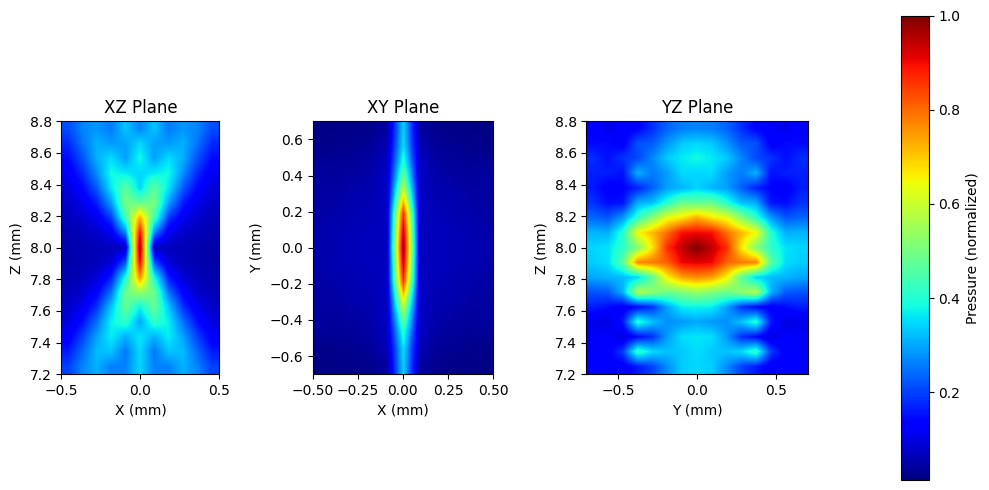

In [304]:
plot_field_planes(pressure_field, x, y, z)

In [305]:
plot_pressure_field(pressure_field, x, y, z)

# 5. Optimized PyField class

In [ ]:
import numpy as np
from tqdm import tqdm
from numba import njit, prange

@njit
def compute_patch_sir(wx, wy, xp, yp, l, c0, apod, delay, sampling_rate_Hz=100e6, lambda_mm):
    # Common sampling rate is 100 MHz
    # Then minimum time step is 0.01 us, 
    epsilon = 1/(2*sampling_rate_Hz) # 1 ns
    Dt1 = min(abs(wx * xp / c0), abs(wy * yp / c0))
    Dt2 = max(abs(wx * xp / c0), abs(wy * yp / c0))
    area = wx * wy / (2 * np.pi * l)

    t1 = l / c0 - 0.5 * (Dt1 + Dt2)
    t2 = t1 + Dt1
    t3 = t1 + Dt2
    t4 = t1 + Dt1 + Dt2

    # peak amplitude
    if not (t1 <= t2 <= t3 <= t4):
        raise ValueError("Invalid time sequence in patch SIR")
    
    width_trapezoid = ((t2 - t1) + (t4 - t3)) * 0.5 + (t3 - t2)
    # avoid division by zero
    if width_trapezoid < epsilon:
        width_trapezoid = epsilon
    # overstimate if point is too close to the patch
    smallest_dimension = min(wx, wy)

    # trapezoid area
    h_max = area * apod / (width_trapezoid)
    return t1 + delay, t2 + delay, t3 + delay, t4 + delay, h_max

@njit(parallel=True)
def compute_all_events(P, M, pts, centers, wx, wy, c, apods, delays, events, sampling_rate_Hz, lambda_mm):
    epsilon = 1e-9 # 1 nm
    for p in prange(P):
        for i in range(M):
            dx = pts[p,0] - centers[i,0]
            dy = pts[p,1] - centers[i,1]
            dz = pts[p,2] - centers[i,2]
            dist = (dx*dx + dy*dy + dz*dz)**0.5
            if dist < epsilon:
                print(f"Warning: Point {p} is too close to patch {i}.")
                
            xp, yp = dx/(dist+ epsilon), dy/(dist)
            t1, t2, t3, t4, h_max = compute_patch_sir(wx, wy, xp, yp, dist, c, apods[i], delays[i], sampling_rate_Hz, lambda_mm)
            events[p,i,0] = t1
            events[p,i,1] = t2
            events[p,i,2] = t3
            events[p,i,3] = t4
            events[p,i,4] = h_max

@njit(parallel=True)
def accumulate_from_events(P, M, events, fs, t0, h_out):
    """
    Parallel accumulation of trapezoidal SIR contributions for all patches.
    events shape: (P, M, 5) storing t1, t2, t3, t4, h_max.
    h_out: (P, n2) output array, t0: start time, fs: sampling rate.
    """
    dt = 1.0 / fs
    n2 = h_out.shape[1]
    for p in prange(P):
        for i in range(M):
            t1, t2, t3, t4, h_max = (
                events[p,i,0], events[p,i,1],
                events[p,i,2], events[p,i,3],
                events[p,i,4]
            )            
            k1 = max(0, int((t1 - t0) * fs)+1)
            k2 = min(n2, int((t2 - t0) * fs)+1)
            k3 = min(n2, int((t3 - t0) * fs)+1)
            k4 = min(n2, int((t4 - t0) * fs)+1)
            
            # rising
            for k in range(k1, k2):
                t = t0 + k * dt
                h_out[p,k] += h_max * ((t - t1) / (t2 - t1))
            # plateau
            for k in range(k2, k3):
                h_out[p,k] += h_max
            # falling
            for k in range(k3, k4):
                t = t0 + k * dt
                h_out[p,k] += h_max * (1 - (t - t3) / (t4 - t3))

class PyField:
    def __init__(self, transducer):
        self.tx = transducer
        self.c = 1540.0 
        self.fs = 100e6 # m/s
        self.fc = transducer.fc # Hz
        self.lambda_mm = self.c / self.fc
        # compute patch centers/apods/delays once
        el_h = self.tx.el_h / self.tx.no_sub_y
        el_w = self.tx.el_w / self.tx.no_sub_x
        centers, apods, delays = [], [], []
        for elem in range(self.tx.n_elements):
            for sub_elem in range(self.tx.no_sub_x * self.tx.no_sub_y):
                verts = self.tx.sub_quad_verts[elem*(self.tx.no_sub_x*self.tx.no_sub_y)+sub_elem]
                centers.append(verts.mean(axis=0))
                apods.append(self.tx.apodization[elem])
                delays.append(self.tx.delays[elem])
        self.centers = np.array(centers, dtype=np.float32)
        self.apods = np.array(apods, dtype=np.float32)
        self.delays = np.array(delays, dtype=np.float32)
        self.wx = el_w
        self.wy = el_h
        
    def show_transducer(self, kwargs= None):
        """
        Visualize the transducer surface mesh and apodization with PyVista.
        """
        mesh = self.tx.get_mesh()
        plotter = pv.Plotter()
        plotter.add_mesh(
            mesh,  # Convert to mm for visualization
            scalars='Apodization',
            cmap='viridis',
            show_scalar_bar=True,
            scalar_bar_args={'title':'Apodization', 'vertical': True},
            opacity=1.0,
            show_edges=True,
        )
        plotter.add_axes()
        plotter.show_grid(font_size = 10, xtitle = "X (mm)", ytitle = "Y (mm)", ztitle = "Z (mm)", show_zlabels=False)
        plotter.show()

    def spatial_impulse_response(self, field_points, return_all=False):

        start_comput_time = TIME()
        pts = np.atleast_2d(field_points).astype(np.float32)
        P, M = pts.shape[0], self.centers.shape[0]
        
        # allocate events
        events = np.zeros((P, M, 5), dtype=np.float32)
        tqdm.write("Computing all patch events...")
        compute_all_events(P, M, pts, self.centers, self.wx, self.wy,
                           self.c, self.apods, self.delays, events, self.fs)
        # build global time vector from real event times
        all_times = np.unique(events[:,:,0:4].ravel())
        all_times.sort()
        t0, tN = all_times[0], all_times[-1]
        # create sampling grid
        dt = 1.0/self.fs
        num_samples = int(np.ceil((tN - t0)*self.fs))
        # next power of two
        n2 = 2**max(int(np.ceil(np.log2(num_samples)))+1, 5)
        t_global = t0 + np.arange(n2, dtype=np.float32)*dt
        h_out = np.zeros((P, n2), dtype=np.float32)
        tqdm.write("Accumulating SIR from events...")
        accumulate_from_events(P, M, events, self.fs, t0, h_out)

        print(f"Total computation time: {TIME() - start_comput_time:.4f} seconds.")
        if return_all:
            return t_global, h_out.T, events
        return t0, h_out.T



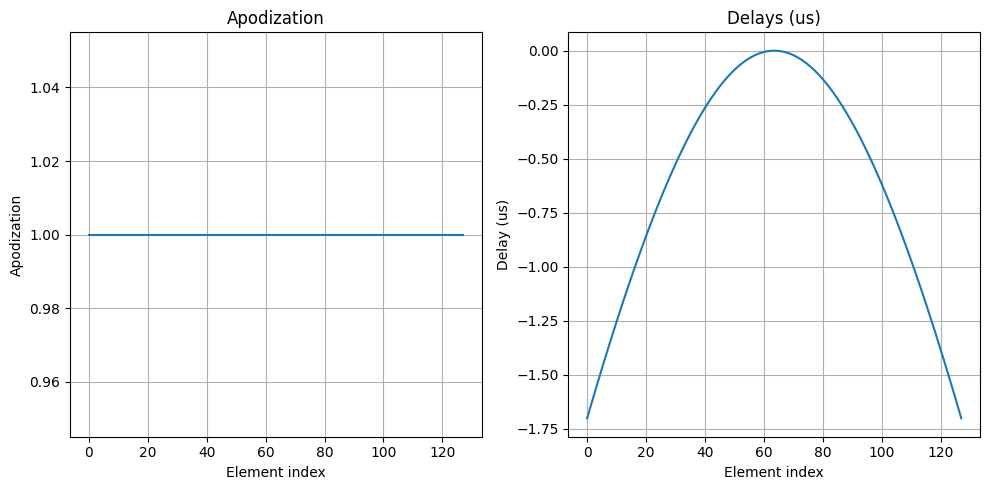

In [307]:
fig = plot_apodization_and_delays(tx)

In [358]:
fieldv1 = PyField_v1(tx)
fieldv2 = PyField(tx)

In [359]:
t_v1, h_v1, events_v1 = fieldv1.spatial_impulse_response(field_point*1e-3, return_all=True)
t_v2, h_v2, events_v2 = fieldv2.spatial_impulse_response(field_point*1e-3, return_all=True)
print(f"Field v1: {h_v1.shape}")
print(f"Field v2: {h_v2.shape}")

Accumulate SIR: 100%|██████████| 1/1 [00:00<00:00, 100.02pt/s]


Total computation time: 0.0155 seconds.
Computing all patch events...
Accumulating SIR from events...
Total computation time: 1.7674 seconds.
Field v1: (256, 1)
Field v2: (256, 1)


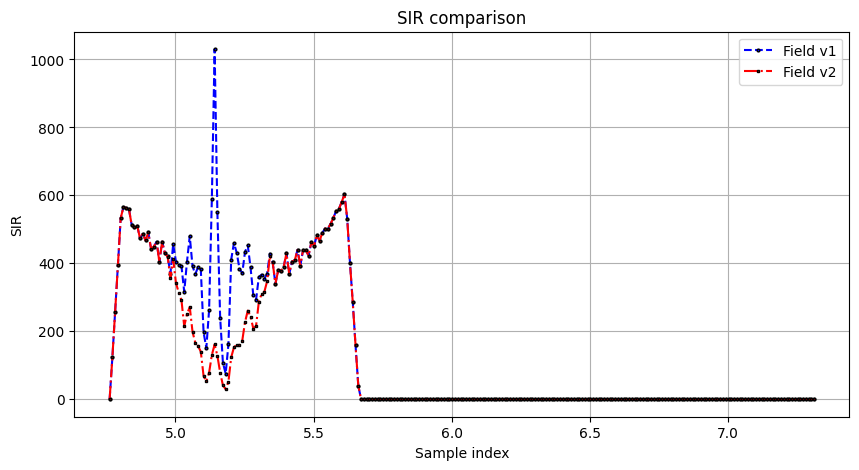

In [360]:
plt.figure(figsize=(10, 5))
plt.plot(t_v1*1e6, h_v1, 'ob--', label="Field v1", ms = 2, markeredgecolor='k')
plt.plot(t_v2*1e6, h_v2, 'sr-.', label="Field v2", ms = 2, markeredgecolor='k')
plt.legend()
plt.title("SIR comparison")
plt.xlabel("Sample index")
plt.ylabel("SIR")
plt.grid()

In [361]:
start_time, h = fieldv2.spatial_impulse_response(grid_points) 

Computing all patch events...
Accumulating SIR from events...
Total computation time: 5.2813 seconds.


In [362]:
pressure_field = compute_pressure_from_SIR(h, x, y, z, [fieldv2.fc, fieldv2.fs])

Original h shape: (256, 25311)
Reshaped h shape: (256, 13, 33, 59)
Frequency searched: 12500000.0 Hz, Closest found: 12549019.607843136 Hz


Taking slice x_ind, y_ind, z_ind = 7/13, 17/33, 30/59


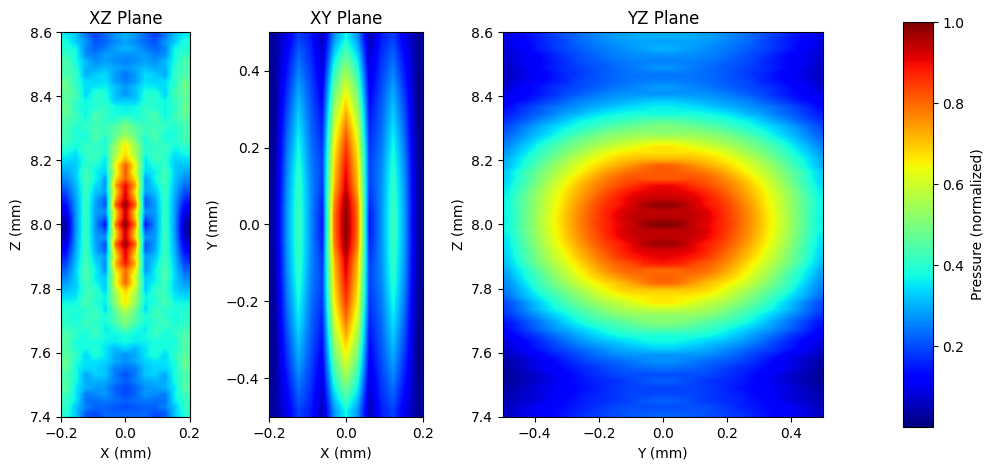

In [363]:
plot_field_planes(pressure_field, x, y, z)

# Let's increase the grid

In [325]:
0.2e-4 # 0.2 mm
time = 0.2e-4 / 1540
print(f"Time for 0.2 mm: {time*1e6} us")

Time for 0.2 mm: 0.012987012987012988 us


In [346]:
simulation_struct = {
    "x_extent" : [-0.2e-3, 0.2e-3],
    "y_extent" : [-0.5e-3, 0.5e-3],
    "z_extent" : [7.4e-3, 8.6e-3],
    "dx" : 0.3e-4,
    "dy" : 0.3e-4,
    "dz" : 0.2e-4,
}

x, y, z, grid_points = create_simulation_grid(simulation_struct)
print(grid_points.shape, x.shape, y.shape, z.shape)

(25311, 3) (13,) (33,) (59,)


In [347]:
start_time, h = fieldv2.spatial_impulse_response(grid_points) 

Computing all patch events...
Accumulating SIR from events...
Total computation time: 5.2634 seconds.


In [348]:
pressure_field = compute_pressure_from_SIR(h, x, y, z, [field.fc, field.fs])

Original h shape: (256, 25311)
Reshaped h shape: (256, 13, 33, 59)
Frequency searched: 12500000.0 Hz, Closest found: 12549019.607843136 Hz


Taking slice x_ind, y_ind, z_ind = 7/13, 17/33, 30/59


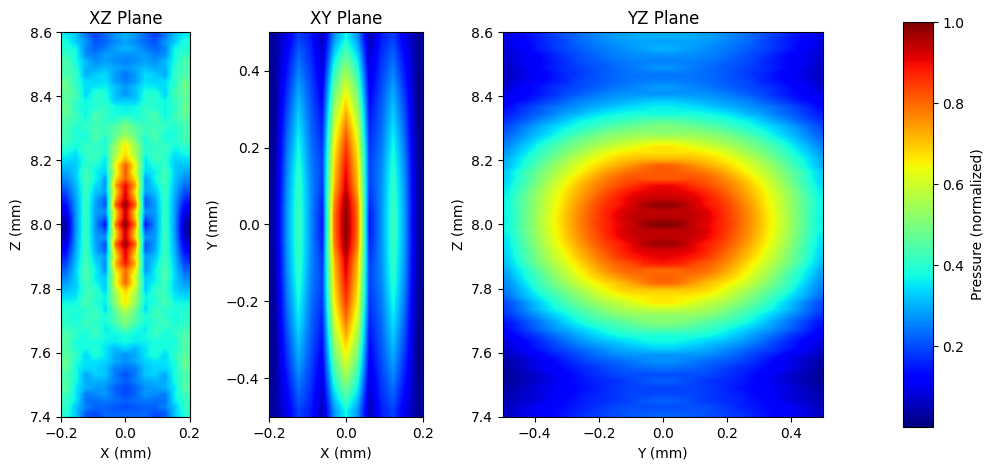

In [364]:
plot_field_planes(pressure_field, x, y, z)

In [318]:
plot_pressure_field(pressure_field, x, y, z)

# 6. Matrix Transducer

In [265]:
import numpy as np
import pyvista as pv
import meshio
from time import time as TIME

class MatrixArrayTransducer:
    """
    Defines a 2D matrix (multi-row) array transducer similar to FieldII's xdc_linear_multirow.
    """
    def __init__(
        self,
        *,
        N_elem_x,
        N_elem_y,
        elem_width_mm,
        elem_height_mm,
        kerf_x_mm,
        kerf_y_mm,
        no_sub_x,
        no_sub_y,
        frequency_Hz=None
    ):
        # Convert mm to meters
        self.n_elem_x = N_elem_x
        self.n_elem_y = N_elem_y
        self.n_elements = N_elem_x * N_elem_y
        self.el_w = elem_width_mm * 1e-3
        self.el_h = elem_height_mm * 1e-3	
        self.kerf_x = kerf_x_mm * 1e-3
        self.kerf_y = kerf_y_mm * 1e-3
        self.no_sub_x = no_sub_x
        self.no_sub_y = no_sub_y
        self.fc = frequency_Hz or 1.0
        # initialize apodization and delays
        total_elements = self.n_elem_x * self.n_elem_y
        self.apodization = np.ones(total_elements, dtype=float)
        self.delays = np.zeros(total_elements, dtype=float)
        # compute element centers in x and y
        total_w = self.n_elem_x * self.el_w + (self.n_elem_x - 1) * self.kerf_x
        total_h = self.n_elem_y * self.el_h + (self.n_elem_y - 1) * self.kerf_y
        start_x = -total_w / 2 + self.el_w / 2
        start_y = -total_h / 2 + self.el_h / 2
        centers = []
        
        for iy in range(self.n_elem_y):
            y = start_y + iy * (self.el_w + self.kerf_y )
            for ix in range(self.n_elem_x):
                x = start_x + ix * (self.el_w + self.kerf_x)
                z = 0.0
                centers.append([x, y, z])
                
        self.element_centers = np.array(centers)
        # subdivisions
        self.sub_quad_verts = []
        self.sub_area = []
        self.sub_el_idx = []
        for idx, center in enumerate(self.element_centers):
            row = idx // self.n_elem_x
            xs = np.linspace(-self.el_w/2, self.el_w/2, self.no_sub_x + 1)
            ys = np.linspace(-self.el_h/2, self.el_h/2, self.no_sub_y + 1)
            for i in range(self.no_sub_x):
                for j in range(self.no_sub_y):
                    corners_local = np.array([
                        [xs[i], ys[j], 0.0], [xs[i+1], ys[j], 0.0],
                        [xs[i+1], ys[j+1], 0.0], [xs[i], ys[j+1], 0.0]
                    ])
                    corners = corners_local + center
                    self.sub_quad_verts.append(corners)
                    self.sub_area.append((self.el_w/self.no_sub_x)*(self.el_h/self.no_sub_y))
                    self.sub_el_idx.append(idx)
        print(f"MatrixArrayTransducer initialized with {total_elements} elements and {len(self.sub_quad_verts)} patches.")

    def set_apodization(self, weights):
        weights = np.asarray(weights, dtype=float)
        if weights.size != self.n_elem_x * self.n_elem_y:
            raise ValueError("Apodization must match total elements")
        self.apodization = weights

    def set_delays(self, delays):
        delays = np.asarray(delays, dtype=float)
        if delays.size != self.n_elem_x * self.n_elem_y:
            raise ValueError("Delays must match total elements")
        self.delays = delays

    def get_mesh(self):
        verts, faces, scalars = [], [], []
        pt_index = 0
        for quad, el_idx in zip(self.sub_quad_verts, self.sub_el_idx):
            verts.extend(quad.tolist())
            faces.append([4, pt_index, pt_index+1, pt_index+2, pt_index+3])
            scalars.append(self.apodization[el_idx])
            pt_index += 4
        verts = np.array(verts)*1e3
        mesh = pv.PolyData(verts, np.hstack(faces))
        mesh.cell_data['Apodization'] = np.array(scalars)
        return mesh


In [266]:
# Create transducer with elevation focus
tx_N_elem_x = 55
tx_N_elem_y = 55
tx_elem_width_mm = 0.29
tx_elem_height_mm = 0.29

tx_pitch_mm = 0.3

tx_kerf_x_mm = tx_pitch_mm - tx_elem_width_mm
tx_kerf_y_mm = tx_pitch_mm - tx_elem_height_mm

tx_freq = 12.5  # MHz

c = 1540.0  # speed of sound in soft tissue (m/s)

Matrix_Trans = MatrixArrayTransducer(
        N_elem_x        = tx_N_elem_x,
        N_elem_y        = tx_N_elem_y,
        elem_width_mm   = tx_elem_width_mm,
        elem_height_mm  = tx_elem_height_mm,
        kerf_x_mm       = tx_kerf_x_mm,
        kerf_y_mm       = tx_kerf_y_mm,
        no_sub_x        = 3,
        no_sub_y        = 3,
        frequency_Hz    = tx_freq*1e6, 
)

MatrixArrayTransducer initialized with 3025 elements and 27225 patches.


In [267]:
apodization = np.hanning(tx_N_elem_y)[np.newaxis].T + np.hanning(tx_N_elem_x)
apodization = apodization / np.max(apodization)
Matrix_Trans.set_apodization(apodization.flatten())

In [268]:

delays = np.linalg.norm(Matrix_Trans.element_centers - focus_mm*1e-3, axis=1) / c
delays = delays.min() - delays  # time delays for focusing
Matrix_Trans.set_delays(delays)

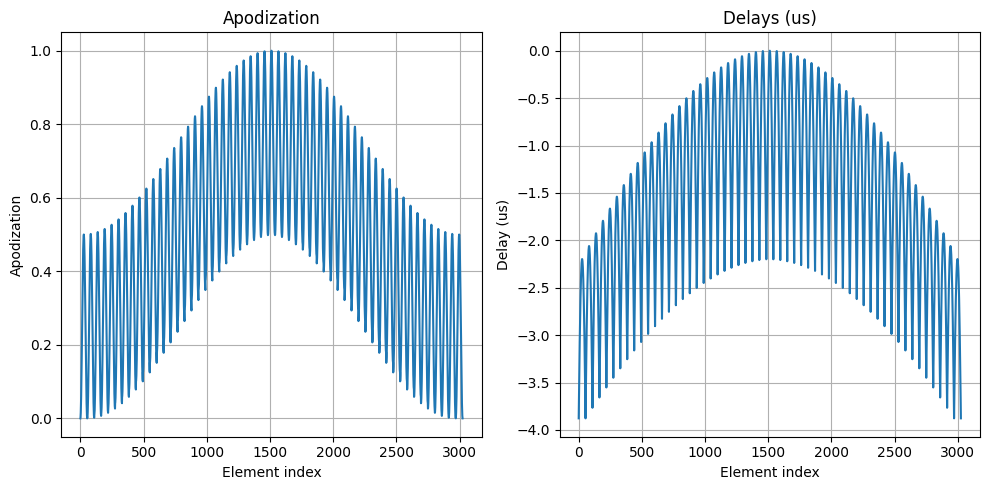

In [269]:
fig = plot_apodization_and_delays(Matrix_Trans)

In [270]:
field = PyField(Matrix_Trans)

In [271]:
field.show_transducer(Matrix_Trans)

Widget(value='<iframe src="http://localhost:60878/index.html?ui=P_0x182eb417a40_5&reconnect=auto" class="pyvis…

In [272]:
simulation_struct = {
    "x_extent" : [-0.3e-3, 0.3e-3],
    "y_extent" : [-0.3e-3, 0.3e-3],
    "z_extent" : [7e-3, 9e-3],
    "dx" : 0.2e-4,
    "dy" : 0.2e-4,
    "dz" : 0.3e-4,
}

x, y, z, grid_points = create_simulation_grid(simulation_struct)
print(grid_points.shape, x.shape, y.shape, z.shape)

(56347, 3) (29,) (29,) (67,)


In [273]:
start_time, h = field.spatial_impulse_response(grid_points) 

Computing all patch events...
Accumulating SIR from events...
Total computation time: 279.8816 seconds.


In [274]:
pressure_field = compute_pressure_from_SIR(h, x, y, z, [field.fc, field.fs])

Original h shape: (512, 56347)
Reshaped h shape: (512, 29, 29, 67)
Frequency searched: 12500000.0 Hz, Closest found: 12524461.839530332 Hz


Taking slice x_ind, y_ind, z_ind = 15/29, 15/29, 34/67


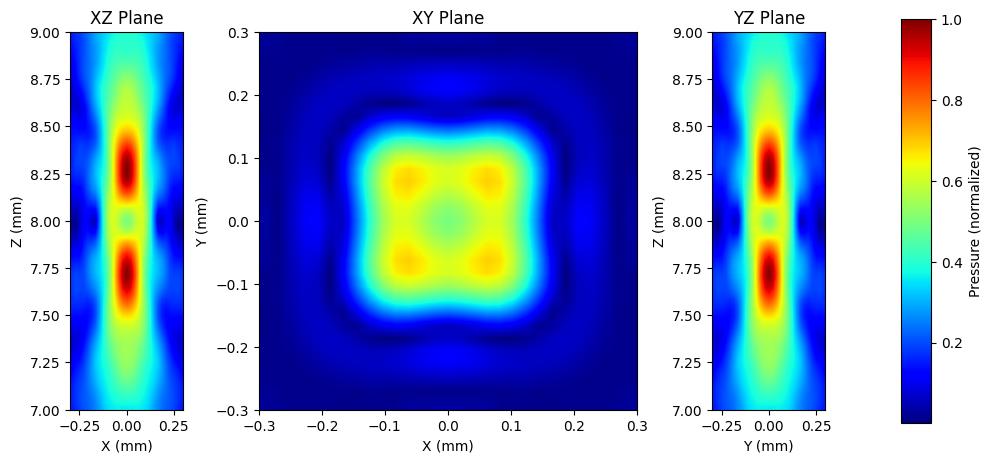

In [275]:
plot_field_planes(pressure_field, x, y, z)